✅ Selected Features by SFS: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Age']

📊 Final Model on Selected Features:
Best Params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1}
MSE  = 37.15
RMSE = 6.09
R²   = 0.8627


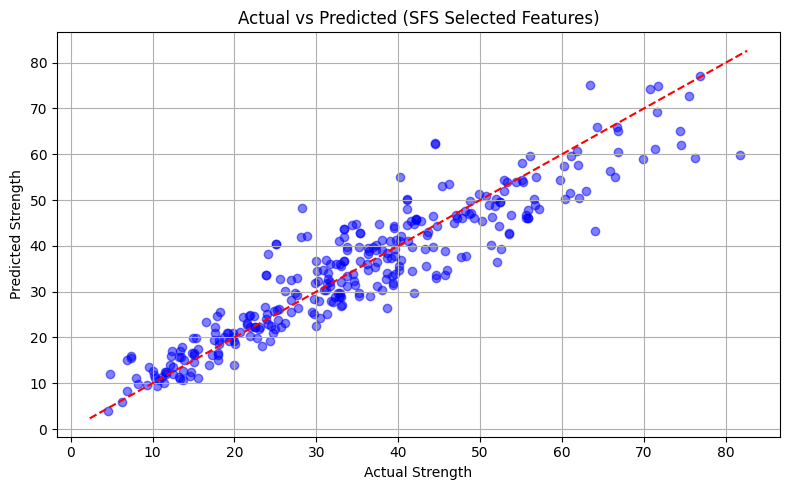

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
# Load dataset
data = fetch_ucirepo(id=165)
X = pd.DataFrame(data.data.features, columns=data.data.headers[:-1])
y = pd.DataFrame(data.data.targets, columns=[data.data.headers[-1]])
# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
   X_scaled, y_scaled, test_size=0.3, random_state=42
)
# Grid search parameters
param_grid = {
   'C': [1, 10, 100],
   'gamma': ['scale', 0.01, 0.1],
   'epsilon': [0.01, 0.1, 1]
}
base_model = SVR(kernel='rbf')
grid = GridSearchCV(base_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_svr = grid.best_estimator_
# Apply Sequential Feature Selector (SFS)
sfs = SFS(best_svr,
         k_features='best',
         forward=True,
         floating=False,
         scoring='neg_mean_squared_error',
         cv=5,
         n_jobs=-1)
sfs = sfs.fit(X_train, y_train)
selected_indices = list(sfs.k_feature_idx_)
selected_features = [X.columns[i] for i in selected_indices]
print(f"✅ Selected Features by SFS: {selected_features}")
# Use only selected features
X_train_sfs = X_train[:, selected_indices]
X_test_sfs = X_test[:, selected_indices]
# Re-train SVR on selected features
final_model = SVR(**grid.best_params_)
final_model.fit(X_train_sfs, y_train)
# Predict and inverse transform
y_pred_scaled = final_model.predict(X_test_sfs)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
# Evaluation
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)
print(f"\n📊 Final Model on Selected Features:")
print(f"Best Params: {grid.best_params_}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")
# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_actual, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted (SFS Selected Features)")
plt.grid(True)
plt.tight_layout()
plt.show()